In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("D:/StudentsPerformance.csv")
print(df.shape)
df.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.columns = df.columns.str.replace(' ', '_').str.replace('/', '_')
print(df.columns.tolist())

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [8]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64
Duplicate rows: 0


In [9]:
df['average_score'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


C:\Users\24jr1\AppData\Local\Temp\ipykernel_17836\398321495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_preparation_course', y='average_score', palette='Set2')


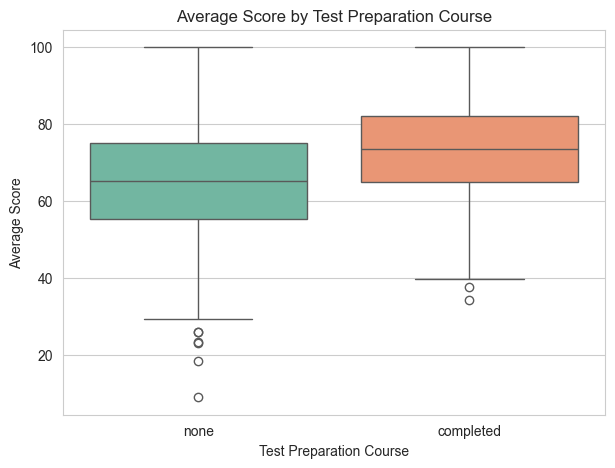

In [11]:
#Does test prep help scores?
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='test_preparation_course', y='average_score', palette='Set2')
plt.title('Average Score by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.show()
#test prep completion is associated with higher average scores.

C:\Users\24jr1\AppData\Local\Temp\ipykernel_17836\4029773166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='parental_level_of_education', y='average_score', order=order, palette='Set2')


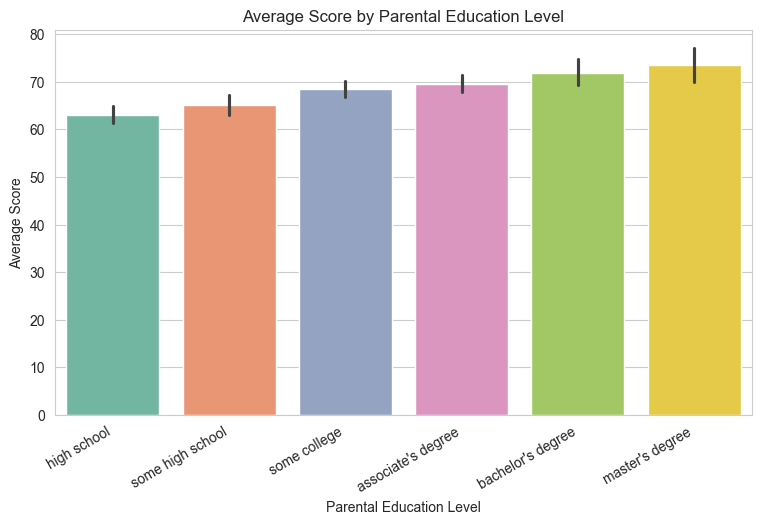

In [12]:
#Does parental education level affect scores?
plt.figure(figsize=(9,5))
order = df.groupby('parental_level_of_education')['average_score'].mean().sort_values().index
sns.barplot(data=df, x='parental_level_of_education', y='average_score', order=order, palette='Set2')
plt.title('Average Score by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Average Score')
plt.xticks(rotation=30, ha='right')
plt.show()
#there's a fairly steady upward trend between parental education level and average student score.

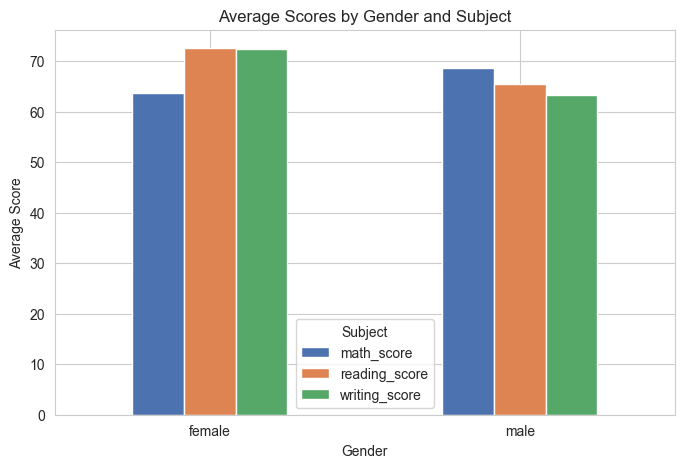

In [13]:
#Gender gap across subjects
gender_avg = df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean()
gender_avg.plot(kind='bar', figsize=(8,5), color=['#4C72B0','#DD8452','#55A868'])
plt.title('Average Scores by Gender and Subject')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.show()

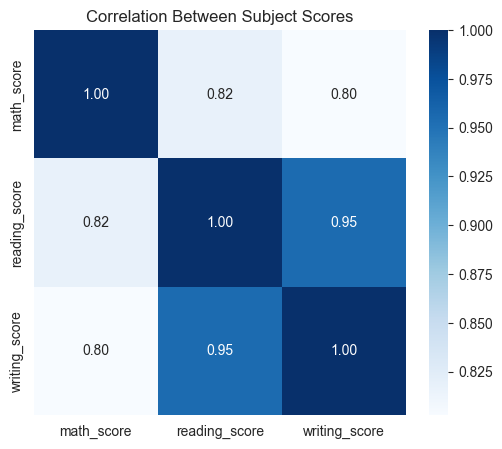

In [14]:
#Correlation between the 3 subject scores
plt.figure(figsize=(6,5))
corr = df[['math_score', 'reading_score', 'writing_score']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Subject Scores')
plt.show()

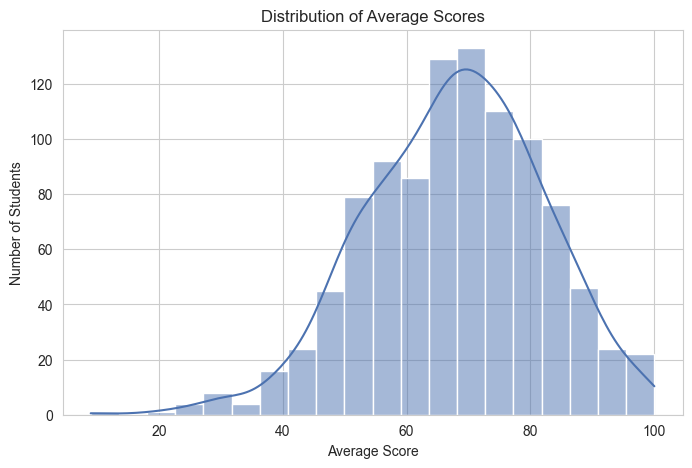

In [15]:
#Distribution of average scores
plt.figure(figsize=(8,5))
sns.histplot(df['average_score'], bins=20, kde=True, color='#4C72B0')
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.show()

## Conclusion

This analysis looked at 1,000 students' exam scores across math, reading, and writing to understand what factors relate to performance.

- **Test preparation matters**: students who completed the test prep course scored noticeably higher on average than those who didn't.
- **Parental education shows a steady positive trend**: average scores rise fairly consistently as parental education level increases, from "some high school" up to advanced degrees.
- **Gender shows a subject-specific split**: males scored higher in math, while females scored higher in both reading and writing — this wasn't a uniform gap in one direction.
- **Reading and writing scores are very strongly correlated (0.95)**, more than either is correlated with math (0.80–0.82), suggesting they draw on more similar underlying skills.
- **Overall scores are roughly normally distributed**, centered around 65-70, which is typical and expected for this kind of exam data.